### 5. Distribuciones Multivariadas

## 5.1 Definiciones

### Una variable aleatoria multivariada o vector aleatorio

### $$X=(X_1,\dots,X_n):\Omega\to \mathbb{R}^n$$

### definida en un espacio de probabilidad $(\Omega,\mathcal{F},\mathbb{P})$ satisface la siguiente propiedad de medibilidad:

### $$X^{-1}(B)\in\mathcal{F}, \qquad \text{para todo } B\in\mathcal{B}(\mathbb{R}^n).$$

### De este modo, se induce de manera natural una medida de probabilidad en el espacio medible $(\mathbb{R}^n,\mathcal{B}(\mathbb{R}^n))$, dada por

### $$\mathbb{P}_X(B):=\mathbb{P}(X\in B), \qquad B\in\mathcal{B}(\mathbb{R}^n).$$

### La función de distribución conjunta de $X=(X_1,\dots,X_n)$ se define por

### $$F(x_1,\dots,x_n):=\mathbb{P}(X_1\le x_1,\dots,X_n\le x_n), \qquad (x_1,\dots,x_n)\in\mathbb{R}^n.$$

## Caso discreto

### En el caso de variables aleatorias multivariadas discretas, es común describir su distribución a partir de la **función de masa conjunta**, definida como

### $$f(x_1,\dots,x_n):=\mathbb{P}(X_1=x_1,\dots,X_n=x_n), \qquad (x_1,\dots,x_n)\in \operatorname{Ran}(X).$$

## Caso continuo

### En el caso continuo, si la distribución conjunta es absolutamente continua, existe una **función de densidad conjunta** $f$ tal que

### $$F(x_1,\dots,x_n)=\int_{-\infty}^{x_1}\cdots\int_{-\infty}^{x_n}f(t_1,\dots,t_n)\,dt_n\cdots dt_1.$$

### Además, cuando la derivada parcial mixta correspondiente existe, la densidad puede obtenerse a partir de la función de distribución conjunta mediante

### $$f(x_1,\dots,x_n)=\frac{\partial^n}{\partial x_1\cdots \partial x_n}F(x_1,\dots,x_n).$$

## Cálculo de probabilidades

### De este modo, el cálculo de probabilidades se realiza del modo siguiente:

### $$\mathbb{P}(X\in A)=\begin{cases}\displaystyle \sum_{x\in A} f(x), & \text{si } X \text{ es discreta},\\[1.2em]\displaystyle \int_A f(x)\,dx, & \text{si } X \text{ es continua},\end{cases}$$

### donde $A\in\mathcal{B}(\mathbb{R}^n)$ y, en el caso continuo, la integral se entiende sobre la región $A\subseteq\mathbb{R}^n$.

## 5.1.1 Ejemplo

## Supóngase que un modelo de clasificación se utiliza para asignar a cada uno de 20 clientes de una base de datos a uno de tres segmentos de comportamiento: 
## - **Segmento 1: clientes de alta actividad**, con probabilidad $p_1=0.40$; 
## - **Segmento 2: clientes de actividad media**, con probabilidad $p_2=0.35$; 
## - **Segmento 3: clientes de baja actividad**, con probabilidad $p_3=0.25$. 
## Se supone que la clasificación de cada cliente es independiente y que cada cliente pertenece exactamente a uno de los tres segmentos. Sean $$ X_1=\text{número de clientes clasificados en el segmento de alta actividad}, $$ $$ X_2=\text{número de clientes clasificados en el segmento de actividad media}, $$ y $$ X_3=\text{número de clientes clasificados en el segmento de baja actividad}. $$ Entonces, el vector aleatorio $$ (X_1,X_2,X_3) $$ representa la distribución de los 20 clientes entre las tres categorías y tiene una distribución multinomial con parámetros $n=20$ y probabilidades $(0.40,0.35,0.25)$: $$ (X_1,X_2,X_3)\sim \operatorname{Multinomial}(20;0.40,0.35,0.25). $$ Su función de masa de probabilidad conjunta está dada por $$ \mathbb P(X_1=x_1,X_2=x_2,X_3=x_3) = \frac{20!}{x_1!\,x_2!\,x_3!} (0.40)^{x_1} (0.35)^{x_2} (0.25)^{x_3}, $$ para valores $x_1,x_2,x_3\geq 0$ que satisfacen $$ x_1+x_2+x_3=20. $$ Por ejemplo, la probabilidad de que el modelo clasifique exactamente a 8 clientes como de alta actividad, 7 como de actividad media y 5 como de baja actividad es $$ \mathbb P(X_1=8,X_2=7,X_3=5) = \frac{20!}{8!\,7!\,5!} (0.40)^8(0.35)^7(0.25)^5. $$ 

In [1]:
from scipy.stats import multinomial

n=20
p=[0.4, 0.35, 0.25]
x=[8, 7, 5]

multinomial.pmf(x, n=n, p=p)

np.float64(0.04108171783716031)

In [2]:
multinomial.rvs(n=n, p=p, size=5)

array([[12,  7,  1],
       [ 9,  6,  5],
       [11,  4,  5],
       [10,  5,  5],
       [ 8,  5,  7]])

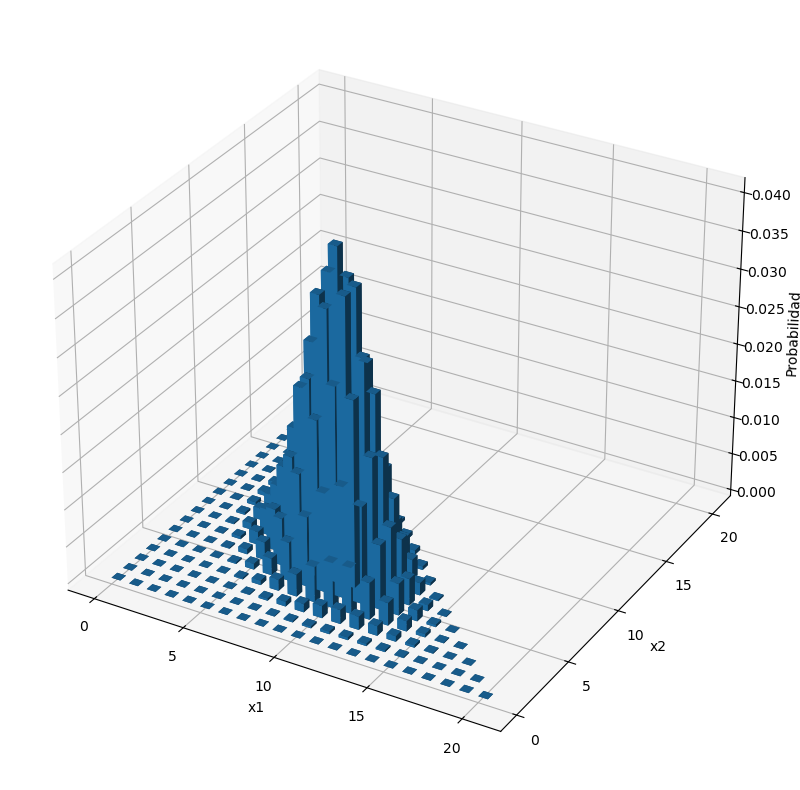

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x=[]
y=[]
z=[]

for x1 in range(n+1):
    for x2 in range(n+1-x1):
        x3=n-x1-x2
        prob = multinomial.pmf([x1, x2, x3], n=n, p=p)
        x.append(x1)
        y.append(x2)
        z.append(prob)

fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(projection='3d')
ax.bar3d(x, y, np.zeros_like(z), 0.5, 0.5, z)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Probabilidad')
plt.show()

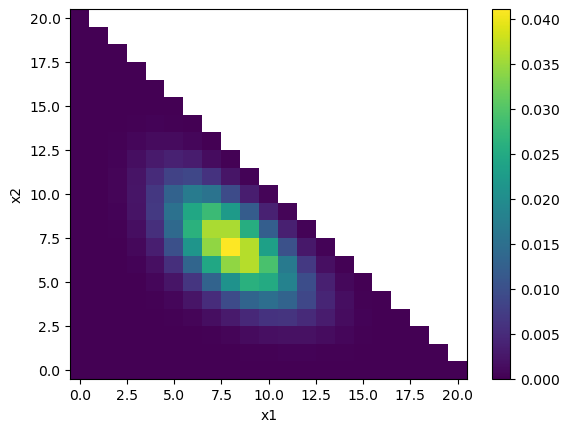

In [4]:
import matplotlib.pyplot as plt
import numpy as np

Z=np.full((n+1, n+1), np.nan)

for x1 in range(n+1):
    for x2 in range(n+1-x1):
        x3=n-x1-x2
        Z[x2, x1]=multinomial.pmf([x1, x2, x3], n=n, p=p)

plt.imshow(Z, origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## 5.2 Independencia

### Sea $(X,Y)$ un vector aleatorio bivariado definido en un espacio de probabilidad $(\Omega,\mathcal{F},\mathbb{P})$. 

### Las variables aleatorias $X$ y $Y$ se dicen **independientes** si, para cualesquiera conjuntos medibles $A,B\subseteq \mathbb{R}$,

### $$\mathbb{P}(X\in A,\;Y\in B)=\mathbb{P}(X\in A)\mathbb{P}(Y\in B).$$

### En términos de la función de distribución conjunta, esto equivale a que

### $$F_{X,Y}(x,y)=F_X(x)\,F_Y(y), \qquad x,y\in\mathbb{R}.$$

### En términos de la función de masa/densidad

### $$f_{X,Y}(x,y)=f_X(x)\,f_Y(y).$$

### La independencia representa una forma fuerte de ausencia de dependencia: conocer el valor de una variable no aporta información adicional sobre la otra.

---

## Covarianza

### Una primera medida para cuantificar la dependencia lineal entre dos variables aleatorias es la **covarianza**, definida por

### $$\operatorname{Cov}(X,Y)=\mathbb{E}\big[(X-\mathbb{E}[X])(Y-\mathbb{E}[Y])\big].$$

### Una expresión equivalente es

### $$\operatorname{Cov}(X,Y)=\mathbb{E}[XY]-\mathbb{E}[X]\mathbb{E}[Y].$$


- ### Si $\operatorname{Cov}(X,Y)>0$, existe una tendencia lineal conjunta creciente.
- ### Si $\operatorname{Cov}(X,Y)<0$, existe una tendencia lineal conjunta decreciente.
- ### Si $\operatorname{Cov}(X,Y)=0$, se dice que las variables son incorreladas.

### La covarianza depende de las unidades de medida de $X$ y $Y$, por lo que no siempre es adecuada para comparar la intensidad de dependencia entre distintos pares de variables.

---

### Para eliminar el efecto de las unidades de medida, se utiliza el **coeficiente de correlación de Pearson**, definido por

### $$\rho_{X,Y}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y},$$

### siempre que $\sigma_X>0$ y $\sigma_Y>0$, donde

### $\sigma_X=\sqrt{\operatorname{Var}(X)}, \qquad \sigma_Y=\sqrt{\operatorname{Var}(Y)}.$

## Propiedades básicas

### El coeficiente de correlación satisface

### $$-1\leq \rho_{X,Y}\leq 1.$$

### Además:

- ### $\rho_{X,Y}=1$ indica dependencia lineal positiva perfecta;
- ### $\rho_{X,Y}=-1$ indica dependencia lineal negativa perfecta;
- ### $\rho_{X,Y}=0$ indica ausencia de dependencia lineal.

### La correlación mide únicamente **dependencia lineal**. Por ello, puede ocurrir que dos variables estén relacionadas de manera no lineal y, sin embargo, tengan correlación igual a cero.

---

### Si $X$ y $Y$ son independientes y tienen momentos de segundo orden finitos, entonces

### $$\operatorname{Cov}(X,Y)=0,$$

### y por tanto $\rho_{X,Y}=0.$

### Sin embargo, el recíproco no es cierto en general.
---

### En el caso bivariado, una forma natural de estudiar la dependencia es a través de los siguientes niveles:

### 1. **Independencia**, verificando si la distribución conjunta se factoriza como producto de las marginales.
### 2. **Covarianza**, para medir la dirección de la dependencia lineal.
### 3. **Correlación**, para medir la intensidad y dirección de la dependencia lineal en una escala estandarizada.
---

## 5.2.1 Ejemplo

### Supongamos que se tiene un conjunto de activos financieros, y estamos interesados en modelar conjuntamente las distribuciones de rendimientos de varios de esos activos. 

[*********************100%***********************]  1 of 2 completed

Ticker      AAPL      MSFT
Ticker                    
AAPL    1.000000  0.477184
MSFT    0.477184  1.000000


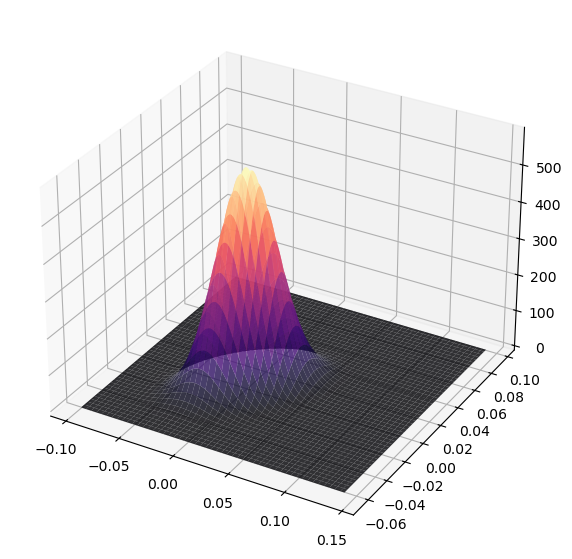

In [ ]:
import yfinance as yf
from scipy.stats import multivariate_normal

tickers=["MSFT", "AAPL"]
data=yf.download(tickers, start="2025-01-01", end="2025-12-31")
precios=data['Close']
rendimientos=np.log(precios / precios.shift(1)).dropna() # queda vacio el primero, shift(1) el anterior, lognormal porque así se comporta el mercado, aprox

mu=rendimientos.mean()
cov_matrix=rendimientos.cov()
corr_matrix=rendimientos.corr()
print(corr_matrix)
va=multivariate_normal(mean=mu, cov=cov_matrix)

x=np.linspace(rendimientos.iloc[:, 0].min(), rendimientos.iloc[:, 0].max(), 200)
y=np.linspace(rendimientos.iloc[:, 1].min(), rendimientos.iloc[:, 1].max(), 200)

X, Y=np.meshgrid(x, y)
Z = va.pdf(np.dstack((X, Y)))

fig=plt.figure(figsize=(10, 7))
ax=fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='none', alpha=0.8)
plt.show()

### ¿Cuál es la probabilidad de que los rendimientos del portafolio se encuentren por debajo del valor promedio?

P((X1,X2)<=(MU1, MU2))  distribución acumulada cdf

In [ ]:
data